# PM2.5-Prognose fuer das Beijing Multi-Site Air-Quality Dataset mit Chronos-2

Dieses Notebook prognostiziert **PM2.5** fuer alle Stationen des UCI-Datensatzes
["Beijing Multi-Site Air Quality Data"](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data)
mit dem Zero-Shot-Foundation-Modell **Chronos-2** (`amazon/chronos-2`).

**Ablauf:**

1. Alle 12 Stations-CSVs laden und zusammenfuehren
2. PM2.5 je Station plotten (EDA)
3. Datenbereinigung: lineare NaN-Interpolation, Windrichtung kategorial -> numerisch,
   Aggregation von Stunden- auf 3-Stunden-Aufloesung
4. Feature Engineering: Kalender, Wetter, chinesisches Neujahrsfest / Feiertage
5. Train/Test-Split: Testzeitraum (`TEST_DAYS`) passend zum max. 72h-Horizont, Rest = Train (=Kontext)
6. Kovariaten-Strategie fuer Chronos-2 (past-only vs. known-future covariates)
7. Multivariate (kovariaten-informierte) Prognose mit Chronos-2, Horizonte 24h/48h/72h, 80%-Konfidenzintervall
8. Sliding-Window-Backtesting ueber den Testzeitraum
9. Auswertung mit MAPE und RMSE, inkl. Ablation (mit vs. ohne exogene Schadstoff-Kovariaten)

**Wichtiger Hinweis zu Chronos-2:** Es handelt sich um ein *Zero-Shot*-Foundation-Modell.
Es gibt hier kein klassisches "Training" mit Gradientenabstieg auf unseren Daten. Der
Trainingszeitraum dient stattdessen als **historischer Kontext**, den das Modell bei
jeder Prognose sieht (In-Context-Learning) - begrenzt auf die letzten `MAX_CONTEXT_POINTS`
Zeitpunkte (Chronos-2-Limit). Das Sliding-Window-Backtesting verschiebt diesen Kontext
schrittweise durch den Testzeitraum.

## 1. Setup & Installation

Chronos-2 wird ueber das Paket `chronos-forecasting` (Version >= 2.0) bereitgestellt.
Fuer die Ausfuehrung auf der GPU wird `device_map="cuda"` verwendet, sonst faellt der
Code automatisch auf CPU zurueck (langsamer, aber funktionsfaehig).

Quellen: [amazon/chronos-2 auf Hugging Face](https://huggingface.co/amazon/chronos-2),
[chronos-forecasting auf GitHub](https://github.com/amazon-science/chronos-forecasting)

In [ ]:
# Benoetigte Pakete installieren (einmalig; bei Bedarf auskommentieren)
# %pip install -q "chronos-forecasting>=2.0" "pandas[pyarrow]" matplotlib numpy scipy

In [91]:
import glob
import os
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RNG_SEED = 42
np.random.seed(RNG_SEED)

# -----------------------------------------------------------------------
# Konfiguration
# -----------------------------------------------------------------------
DATA_DIR = r"C:\Users\betti\Desktop\Individual\beijing+multi+site+air+quality+data\PRSA2017_Data_20130301-20170228\PRSA_Data_20130301-20170228"  # Ordner, in dem die 12 PRSA_Data_*.csv-Dateien liegen
FILE_PATTERN = os.path.join(DATA_DIR, "PRSA_Data_*.csv")

TARGET_COL = "PM2.5"

# Exogene Faktoren laut Aufgabenstellung
POLLUTANT_COVARIATES = ["SO2", "NO2", "CO", "O3"]          # NICHT im Voraus bekannt -> past-only covariates
#WEATHER_COVARIATES = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]  # im Voraus bekannt (z.B. Wettervorhersage) -> known-future covariates
WEATHER_COVARIATES = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
# Die Rohdaten liegen stuendlich vor. Wir aggregieren auf 3h-Aufloesung, damit die
# maximale Chronos-2-Kontextlaenge (8192 Punkte, siehe MAX_CONTEXT_POINTS) ~2,8 Jahre
# statt nur ~341 Tage Historie abdeckt und so volle Jahreszyklen (Saisonalitaet,
# Heizperiode etc.) im Kontext sichtbar bleiben. Alle Prognosehorizonte muessen
# durch STEP_HOURS teilbar sein.
AGG_RULE = "6h"
STEP_HOURS = 6  # Zeitschritt nach der Aggregation, in Stunden

# Prognosehorizont: maximal 72h gewuenscht (kein 7-Tage-Horizont mehr)
HORIZONS = {"24h": 24, "48h": 48, "72h": 72}  # Prognosehorizonte in Stunden
MAX_HORIZON = max(HORIZONS.values())

# Testzeitraum bewusst klein gehalten: er muss nur so gross sein, dass genuegend
# Backtest-Ursprungszeitpunkte mit max. 72h-Horizont hineinpassen - nicht 12 Monate
# wie bei einem 7-Tage-Horizont. Der Rest der Daten dient als Trainings-/Kontextzeitraum.
TEST_DAYS = 30

# Chronos-2 hat laut Modellkarte eine maximale Kontextlaenge von 8192 Zeitpunkten.
# Laengere Historien werden von der Pipeline sonst STILLSCHWEIGEND auf die letzten
# 8192 Punkte gekuerzt. Bei 3h-Aufloesung entspricht das ~2,8 Jahren (8192 * 3h).
# Wir kuerzen den Kontext daher explizit selbst (in Punkten, nicht Stunden).
MAX_CONTEXT_POINTS = 4096
CONF_LEVEL = 0.80
ALPHA = (1 - CONF_LEVEL) / 2
QUANTILE_LEVELS = [ALPHA, 0.5, 1 - ALPHA]  # -> [0.1, 0.5, 0.9] fuer 80% CI
Q_LOW, Q_MED, Q_HIGH = [str(q) for q in QUANTILE_LEVELS]

CHRONOS_MODEL_ID = "amazon/chronos-2"

print(f"Quantile fuer {int(CONF_LEVEL*100)}%-Konfidenzintervall: {QUANTILE_LEVELS}")

Quantile fuer 80%-Konfidenzintervall: [0.09999999999999998, 0.5, 0.9]


## 2. Daten laden (alle Stationen)

Der Datensatz besteht aus 12 CSV-Dateien (`PRSA_Data_<Station>_<Zeitraum>.csv`), eine pro
Messstation. Das Skript liest **alle** Dateien ein, die dem Muster entsprechen (`DATA_DIR`
zeigt auf den entpackten UCI-Ordner mit allen 12 Dateien).

In [92]:
def load_all_stations(pattern: str) -> pd.DataFrame:
    '''Laedt alle PRSA_Data_*.csv-Dateien und haengt sie zu einem Long-Format-DataFrame zusammen.'''
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f"Keine Dateien gefunden unter Muster: {pattern}. "
            "Bitte alle 12 PRSA_Data_*.csv-Dateien des UCI-Datensatzes in DATA_DIR ablegen."
        )
    frames = []
    for f in files:
        df_station = pd.read_csv(f)
        frames.append(df_station)
    df_all = pd.concat(frames, ignore_index=True)

    # Zeitstempel aus year/month/day/hour bauen
    df_all["timestamp"] = pd.to_datetime(df_all[["year", "month", "day", "hour"]])

    # Aufraeumen: Hilfsspalten entfernen, sortieren
    df_all = df_all.drop(columns=["No"], errors="ignore")
    df_all = df_all.sort_values(["station", "timestamp"]).reset_index(drop=True)
    return df_all


raw_df = load_all_stations(FILE_PATTERN)
stations = sorted(raw_df["station"].unique())
print(f"Gefundene Stationen ({len(stations)}): {stations}")
print(f"Zeitraum: {raw_df['timestamp'].min()} bis {raw_df['timestamp'].max()}")
raw_df.head()

Gefundene Stationen (12): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Zeitraum: 2013-03-01 00:00:00 bis 2017-02-28 23:00:00


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,timestamp
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [93]:
# Ueberblick ueber fehlende Werte je Spalte (ueber alle Stationen)
missing_overview = raw_df.isna().sum().to_frame("n_missing")
missing_overview["pct_missing"] = (missing_overview["n_missing"] / len(raw_df) * 100).round(2)
missing_overview

,n_missing,pct_missing
year,0,0.00
month,0,0.00
day,0,0.00
hour,0,0.00
PM2.5,8739,2.08
PM10,6449,1.53
SO2,9021,2.14
NO2,12116,2.88
CO,20701,4.92
O3,13277,3.16


## 3. Explorative Analyse: PM2.5 je Station

Zeitreihen-Plot von PM2.5 fuer jede Station (rohe, ungefilterte Werte inkl. Luecken durch NaNs).

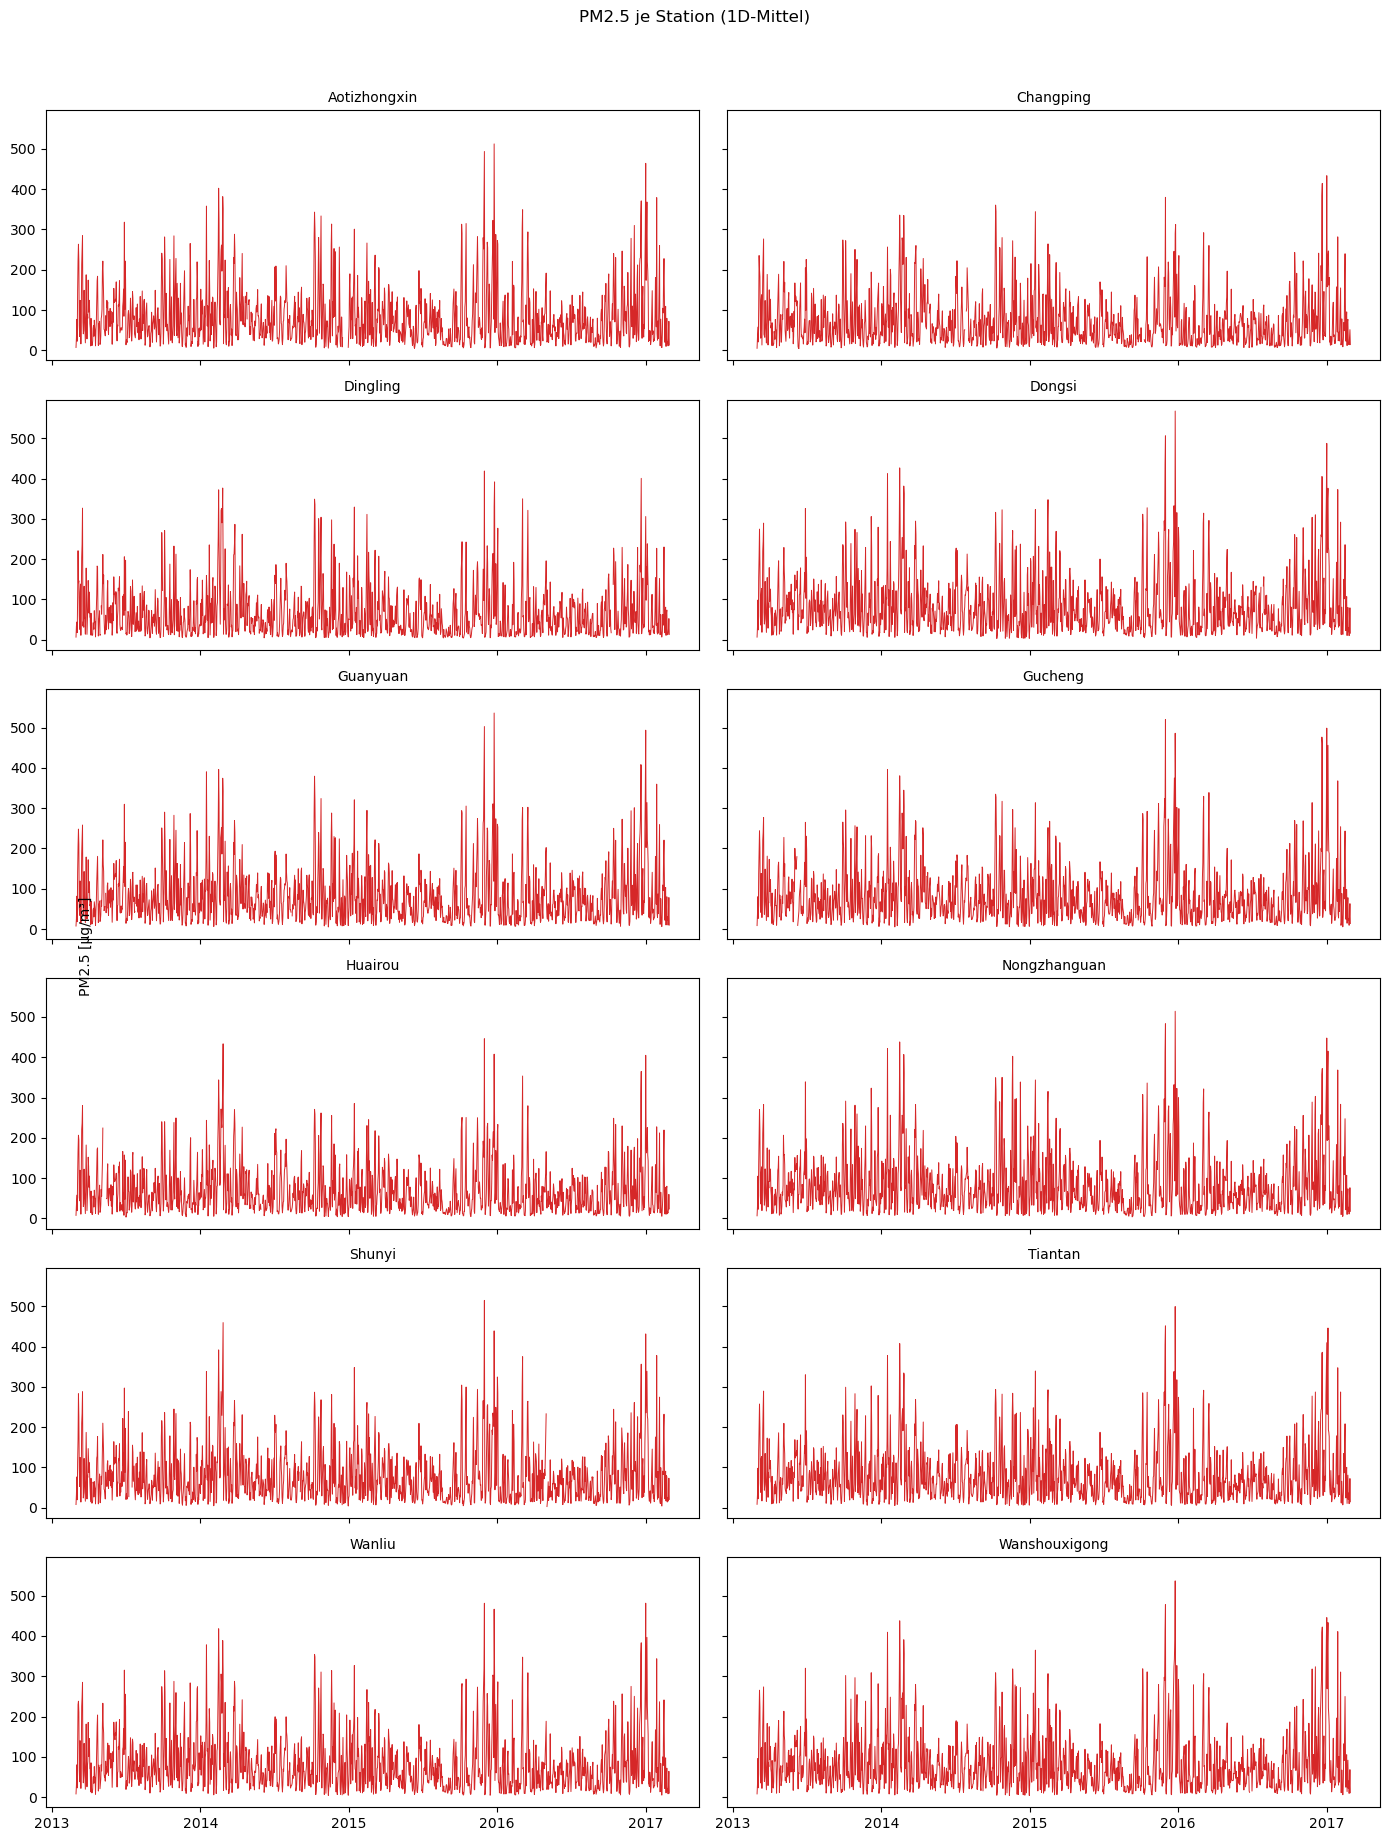

In [94]:
def plot_pm25_all_stations(df: pd.DataFrame, resample_rule: str | None = "1D"):
    '''Plottet PM2.5 je Station in einem Subplot-Grid.

    resample_rule: falls gesetzt, wird vor dem Plotten auf Tagesmittel (o.ae.) aggregiert,
    um die Grafik bei 4 Jahren Stundendaten lesbar zu halten.
    '''
    stations_local = sorted(df["station"].unique())
    n = len(stations_local)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, st in zip(axes, stations_local):
        s = df.loc[df["station"] == st].set_index("timestamp")[TARGET_COL]
        if resample_rule:
            s = s.resample(resample_rule).mean()
        ax.plot(s.index, s.values, linewidth=0.7, color="tab:red")
        ax.set_title(st, fontsize=10)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"PM2.5 je Station" + (f" ({resample_rule}-Mittel)" if resample_rule else ""), y=1.02)
    fig.text(0.06, 0.5, "PM2.5 [µg/m³]", va="center", rotation="vertical")
    plt.tight_layout()
    plt.show()


plot_pm25_all_stations(raw_df, resample_rule="1D")

## 4. Datenbereinigung

### 4.1 Fehlende Werte (NaNs)

Alle numerischen Messspalten (inkl. der Zielvariable PM2.5) enthalten vereinzelt NaNs
(ca. 0.1-4 % je Spalte, `CO` am staerksten betroffen). Strategie je Station:

1. **Lineare Interpolation** (`interpolate(method="linear")`) ueber die gesamte Spalte,
   ohne Laengenlimit - PM2.5 & Wetter sind stundenweise stark autokorreliert, eine
   lineare Interpolation ist daher auch ueber laengere Luecken plausibel. Die
   Interpolation erfolgt bewusst **vor** der spaeteren 3h-Aggregation (Abschnitt 4.3),
   damit dort keine teilweise NaN-haltigen Zeitfenster gemittelt werden.
2. **Forward-/Backward-Fill** als Fallback ausschliesslich fuer Werte am Rand der
   Zeitreihe (z.B. NaNs ganz am Anfang/Ende einer Station), fuer die lineare
   Interpolation keine zwei Stuetzpunkte hat.

Die Bereinigung erfolgt **getrennt je Station**, damit keine Werte zwischen Stationen
"durchsickern".

In [95]:
NUMERIC_COLS = [TARGET_COL, "PM10"] + POLLUTANT_COVARIATES + WEATHER_COVARIATES


def clean_numeric_gaps(df: pd.DataFrame, cols=NUMERIC_COLS) -> pd.DataFrame:
    '''Fuellt NaNs in numerischen Spalten je Station: reine lineare Interpolation
    (kein Laengenlimit) + ffill/bfill als Fallback fuer Werte am Rand der Zeitreihe.'''
    df = df.copy()
    filled_parts = []
    for st, g in df.groupby("station", sort=False):
        g = g.sort_values("timestamp").set_index("timestamp")
        g[cols] = (
            g[cols]
            .interpolate(method="linear", limit_direction="both")
            .ffill()
            .bfill()
        )
        filled_parts.append(g.reset_index())
    return pd.concat(filled_parts, ignore_index=True).sort_values(["station", "timestamp"]).reset_index(drop=True)


n_missing_before = raw_df[NUMERIC_COLS].isna().sum().sum()
df_clean = clean_numeric_gaps(raw_df)
n_missing_after = df_clean[NUMERIC_COLS].isna().sum().sum()
print(f"Fehlende numerische Werte vorher: {n_missing_before}, nachher: {n_missing_after}")

Fehlende numerische Werte vorher: 72205, nachher: 0


### 4.2 Windrichtung (`wd`) - kategorial, nicht numerisch

`wd` ist als 16-Punkte-Kompassrichtung (`N, NNE, NE, ... NNW`) codiert, also **kategorial**
und **zyklisch** (N liegt "neben" NNW und NNE). Wir gehen zweigleisig vor:

- **`wd_sin` / `wd_cos`**: klassische zyklische Kodierung (Grad -> Bogenmass -> sin/cos),
  nuetzlich fuer Plots/EDA und als numerischer Fallback.
- **`wd` als String-Kategorie** (fehlende Werte -> `"missing"`): Chronos-2 unterstuetzt
  **kategoriale Kovariaten nativ** (siehe Modellkarte), daher uebergeben wir die
  Windrichtung im Chronos-2-Aufruf direkt als kategoriale Spalte statt sie in sin/cos
  zu zerlegen - das vermeidet die (falsche) Annahme, das Modell koenne die
  Zyklizitaet aus zwei linearen Kanaelen selbst ableiten.

In [96]:
COMPASS_16 = ["N","NNE","NE","ENE","E","ESE","SE","SSE","S","SSW","SW","WSW","W","WNW","NW","NNW"]
COMPASS_DEGREES = {d: i * 22.5 for i, d in enumerate(COMPASS_16)}


def encode_wind_direction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    deg = df["wd"].map(COMPASS_DEGREES)
    rad = np.deg2rad(deg)
    df["wd_sin"] = np.sin(rad)
    df["wd_cos"] = np.cos(rad)
    # zyklische Luecken zuerst je Station per ffill/bfill schliessen (kurze Aussetzer),
    # danach verbleibende NaNs (z.B. am Rand) als eigene Kategorie behandeln
    df["wd_sin"] = df.groupby("station")["wd_sin"].transform(lambda s: s.ffill().bfill())
    df["wd_cos"] = df.groupby("station")["wd_cos"].transform(lambda s: s.ffill().bfill())
    df["wd_cat"] = df["wd"].fillna("missing").astype("category")
    return df


df_clean = encode_wind_direction(df_clean)
df_clean[["wd", "wd_cat", "wd_sin", "wd_cos"]].head()

,wd,wd_cat,wd_sin,wd_cos
0,NNW,NNW,-0.382683,0.923880
1,N,N,0.000000,1.000000
2,NNW,NNW,-0.382683,0.923880
3,NW,NW,-0.707107,0.707107
4,N,N,0.000000,1.000000


### 4.3 Aggregation auf 3-Stunden-Aufloesung

Um saisonale Effekte (volle Jahreszyklen: Heizperiode, Sommer/Winter-Unterschiede)
trotz der Chronos-2-Kontextgrenze von 8192 Punkten im Kontext sichtbar zu halten,
aggregieren wir alle Groessen von Stunden- auf **3-Stunden-Aufloesung**
(`AGG_RULE`, siehe Konfiguration):

- **Mittelwert** fuer Zielvariable, Schadstoffe und Wettergroessen (TEMP, PRES, DEWP, WSPM)
  sowie fuer `wd_sin`/`wd_cos`.
- **Summe** fuer `RAIN` (Niederschlag akkumuliert sich ueber das Zeitfenster).
- **Windrichtung**: `wd_cat` wird **nicht** per Modus, sondern korrekt zirkulaer aus dem
  gemittelten `wd_sin`/`wd_cos`-Vektor zurueckgerechnet (naechstgelegene der 16
  Kompassrichtungen), da eine einfache Mehrheitsentscheidung bei Windrichtung
  physikalisch nicht sinnvoll waere.

Bei `MAX_CONTEXT_POINTS = 8192` deckt der Kontext dadurch ~2,8 Jahre statt ~341 Tage ab.
Alle drei Prognosehorizonte (24h/48h/72h) sind durch 3 teilbar und passen daher exakt
auf das neue Raster. Die Aggregation erfolgt **nach** NaN-Interpolation (4.1) und
Windrichtungs-Kodierung (4.2), aber **vor** den Kalender-/Feiertagsfeatures (Abschnitt 5),
damit diese direkt auf dem finalen 3h-Raster berechnet werden.

In [97]:
MEAN_COLS = [TARGET_COL, "PM10"] + POLLUTANT_COVARIATES + ["TEMP", "PRES", "DEWP", "WSPM", "wd_sin", "wd_cos"]
SUM_COLS = ["RAIN"]


def aggregate_to_resolution(df: pd.DataFrame, rule: str = AGG_RULE) -> pd.DataFrame:
    '''Aggregiert alle Stationen von Stunden- auf `rule`-Aufloesung (Standard: 3h).

    Numerische Groessen (Zielvariable, Schadstoffe, Wetter, wd_sin/wd_cos) werden
    gemittelt, RAIN aufsummiert. Die Windrichtung wird aus dem gemittelten
    sin/cos-Vektor zirkulaer zurueckgerechnet statt per Modus bestimmt.
    '''
    parts = []
    for st, g in df.groupby("station", sort=False):
        g = g.set_index("timestamp").sort_index()
        agg = pd.concat([
            g[MEAN_COLS].resample(rule).mean(),
            g[SUM_COLS].resample(rule).sum(),
        ], axis=1)
        agg["station"] = st
        parts.append(agg.reset_index())

    df_agg = pd.concat(parts, ignore_index=True)

    deg = np.degrees(np.arctan2(df_agg["wd_sin"], df_agg["wd_cos"])) % 360
    compass_idx = (deg / 22.5).round().astype(int) % 16
    df_agg["wd_cat"] = pd.Categorical([COMPASS_16[i] for i in compass_idx], categories=COMPASS_16)

    return df_agg.sort_values(["station", "timestamp"]).reset_index(drop=True)


n_rows_before_agg = len(df_clean)
df_clean = aggregate_to_resolution(df_clean)
print(f"Zeilen vor Aggregation (stuendlich): {n_rows_before_agg}")
print(f"Zeilen nach Aggregation auf {AGG_RULE}:  {len(df_clean)}")
df_clean[["station", "timestamp", TARGET_COL, "wd_cat", "wd_sin", "wd_cos", "RAIN"]].head()

Zeilen vor Aggregation (stuendlich): 420768
Zeilen nach Aggregation auf 6h:  70128


,station,timestamp,PM2.5,wd_cat,wd_sin,wd_cos,RAIN
0,Aotizhongxin,2013-03-01 00:00:00,5.500000,NNW,-0.245412,0.925811,0.0
1,Aotizhongxin,2013-03-01 06:00:00,3.000000,N,-0.127561,0.949253,0.0
2,Aotizhongxin,2013-03-01 12:00:00,6.500000,NNW,-0.235702,0.851622,0.0
3,Aotizhongxin,2013-03-01 18:00:00,13.500000,NE,0.525720,0.678655,0.0
4,Aotizhongxin,2013-03-02 00:00:00,10.666667,NNE,0.448208,0.679700,0.0


## 5. Feature Engineering: Kalender & Feiertage

### 5.1 Kalender-Features
Stunde, Wochentag, Monat und Wochenende sind fuer PM2.5 relevant (z.B. Verkehrsspitzen,
Heizperiode, Wochenendeffekte) und **beliebig weit im Voraus bekannt**.

### 5.2 Chinesisches Neujahrsfest (Chunjie)
Rund um das chinesische Neujahrsfest veraendert sich die PM2.5-Belastung in Peking
typischerweise deutlich (Feuerwerk kurz nach Neujahr, gleichzeitig Werksschliessungen /
weniger Verkehr durch die Reisewelle). Da der Termin nach dem Mondkalender jedes Jahr
verschiebt, kann ihn ein Modell nicht aus Monat/Tag allein lernen - wir geben ihn daher
explizit als Feature mit:

| Jahr | Datum Neujahrsfest |
|---|---|
| 2013 | 10.02.2013 |
| 2014 | 31.01.2014 |
| 2015 | 19.02.2015 |
| 2016 | 08.02.2016 |
| 2017 | 28.01.2017 |

Daraus bauen wir:
- `days_to_cny`: vorzeichenbehafteter Abstand in Tagen zum naechstgelegenen Neujahrsfest
  (negativ = davor, positiv = danach) - numerisch, stetig, beliebig weit in die Zukunft
  berechenbar.
- `cny_window`: binaeres Flag, ob der Zeitpunkt innerhalb eines Fensters von +/- 7 Tagen
  um das Neujahrsfest liegt (Reisewelle + Feuerwerk-Effekt).

### 5.3 Weitere chinesische Feiertage (ergaenzend)
Zusaetzlich zum Neujahrsfest ("insbesondere") beruecksichtigen wir grob die uebrigen
grossen offiziellen Feiertage (Neujahr, Tag der Arbeit, Nationalfeiertag/Golden Week) als
einfaches binaeres `is_public_holiday`-Flag. Die exakten, jaehrlich amtlich verschobenen
Ersatz-Arbeitstage werden dabei bewusst **nicht** nachgebildet (dafuer waere ein
gepflegter chinesischer Feiertagskalender noetig) - das Flag ist ein grober Zusatzindikator,
der Neujahrsfest-Analyse bleibt die praezise Komponente.

In [98]:
CNY_DATES = pd.to_datetime(list({
    2013: "2013-02-10",
    2014: "2014-01-31",
    2015: "2015-02-19",
    2016: "2016-02-08",
    2017: "2017-01-28",
    # Randjahre fuer saubere "naechstgelegen"-Berechnung an den Raendern des Datensatzes
    2012: "2012-01-23",
    2018: "2018-02-16",
}.values()))

# Weitere grosse chinesische Feiertage (grobe, nicht amtlich exakte Naeherung),
# jeweils als (Start, Ende)-Datum
OTHER_HOLIDAYS = [
    ("2013-01-01", "2013-01-01"), ("2013-04-29", "2013-05-01"), ("2013-10-01", "2013-10-07"),
    ("2014-01-01", "2014-01-01"), ("2014-05-01", "2014-05-01"), ("2014-10-01", "2014-10-07"),
    ("2015-01-01", "2015-01-01"), ("2015-05-01", "2015-05-03"), ("2015-10-01", "2015-10-07"),
    ("2016-01-01", "2016-01-03"), ("2016-05-01", "2016-05-02"), ("2016-10-01", "2016-10-07"),
    ("2017-01-01", "2017-01-02"), ("2017-05-01", "2017-05-01"),
]
OTHER_HOLIDAYS = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in OTHER_HOLIDAYS]

CNY_WINDOW_DAYS = 7


def add_calendar_and_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    ts = df["timestamp"]

    # -- einfache Kalender-Features --
    df["hour"] = ts.dt.hour
    df["dow"] = ts.dt.dayofweek           # 0 = Montag
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)

    # -- chinesisches Neujahrsfest --
    dates_only = ts.dt.normalize()
    # Fuer jeden Zeitpunkt den Tagesabstand zu allen CNY-Terminen berechnen und das Minimum (nach Betrag) waehlen
    diffs = np.subtract.outer(dates_only.values.astype("datetime64[D]"), CNY_DATES.values.astype("datetime64[D]"))
    diffs_days = diffs / np.timedelta64(1, "D")
    idx_min = np.abs(diffs_days).argmin(axis=1)
    df["days_to_cny"] = diffs_days[np.arange(len(df)), idx_min].astype(int)
    df["cny_window"] = (df["days_to_cny"].abs() <= CNY_WINDOW_DAYS).astype(int)

    # -- sonstige Feiertage --
    is_holiday = pd.Series(False, index=df.index)
    for start, end in OTHER_HOLIDAYS:
        is_holiday |= dates_only.between(start, end)
    df["is_public_holiday"] = (is_holiday | (df["cny_window"] == 1)).astype(int)

    return df


df_clean = add_calendar_and_holiday_features(df_clean)
df_clean[["timestamp", "hour", "dow", "is_weekend", "days_to_cny", "cny_window", "is_public_holiday"]].sample(5, random_state=RNG_SEED)

,timestamp,hour,dow,is_weekend,days_to_cny,cny_window,is_public_holiday
32189,2015-03-13 06:00:00,6,4,0,22,0,0
41315,2013-06-10 18:00:00,18,0,0,120,0,0
57975,2016-11-04 18:00:00,18,4,0,-85,0,0
14401,2015-01-08 06:00:00,6,3,0,-42,0,0
8550,2015-01-06 12:00:00,12,1,0,-44,0,0


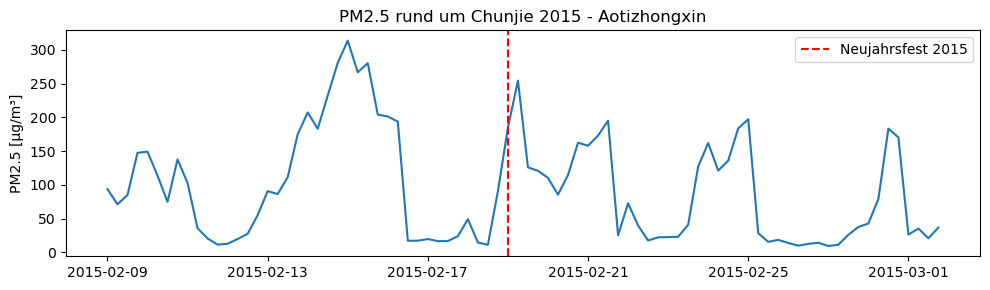

In [99]:
# Sichtcheck: PM2.5 rund um ein Neujahrsfest (hier 2015) - typischer Feuerwerk-Peak kurz nach Neujahr
example_station = stations[0]
mask = (df_clean["station"] == example_station) & (df_clean["days_to_cny"].abs() <= 10) & (df_clean["timestamp"].dt.year.isin([2015]))
sub = df_clean.loc[mask].sort_values("timestamp")
plt.figure(figsize=(10, 3))
plt.plot(sub["timestamp"], sub[TARGET_COL])
plt.axvline(pd.Timestamp("2015-02-19"), color="red", linestyle="--", label="Neujahrsfest 2015")
plt.title(f"PM2.5 rund um Chunjie 2015 - {example_station}")
plt.ylabel("PM2.5 [µg/m³]")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Train/Test-Split (Testzeitraum passend zum 72h-Horizont)

Bisher wurde ein fixer 36/12-Monats-Split verwendet - das war fuer einen 7-Tage-Horizont
gedacht, ist fuer einen **maximalen Prognosehorizont von 72h** aber unnoetig gross.
Der Testzeitraum muss nur so viele Tage umfassen, dass genuegend Sliding-Window-
Backtest-Ursprungszeitpunkte mit 72h-Vorlauf hineinpassen (`TEST_DAYS`, siehe
Konfiguration). Der restliche, deutlich groessere Teil der Daten dient als
Trainings-/Kontextzeitraum (auch wenn davon wegen `MAX_CONTEXT_POINTS` ohnehin nur
die juengsten ~2,8 Jahre je Prognose tatsaechlich als Kontext verwendet werden).
Der Split erfolgt je Station identisch (gleicher Zeitpunkt), damit alle Stationen im
selben Testfenster ausgewertet werden.

In [100]:
def train_test_split_by_days(df: pd.DataFrame, test_days: int = TEST_DAYS):
    t_max = df["timestamp"].max()
    test_start = t_max - pd.Timedelta(days=test_days)
    train_df = df.loc[df["timestamp"] < test_start].copy()
    test_df = df.loc[df["timestamp"] >= test_start].copy()
    return train_df, test_df, test_start


train_df, test_df, TRAIN_END = train_test_split_by_days(df_clean)
print(f"Trainingszeitraum: {df_clean['timestamp'].min()} bis {TRAIN_END} ({len(train_df)} Zeilen)")
print(f"Testzeitraum:      {TRAIN_END} bis {df_clean['timestamp'].max()} ({len(test_df)} Zeilen, {TEST_DAYS} Tage)")

Trainingszeitraum: 2013-03-01 00:00:00 bis 2017-01-29 18:00:00 (68676 Zeilen)
Testzeitraum:      2017-01-29 18:00:00 bis 2017-02-28 18:00:00 (1452 Zeilen, 30 Tage)


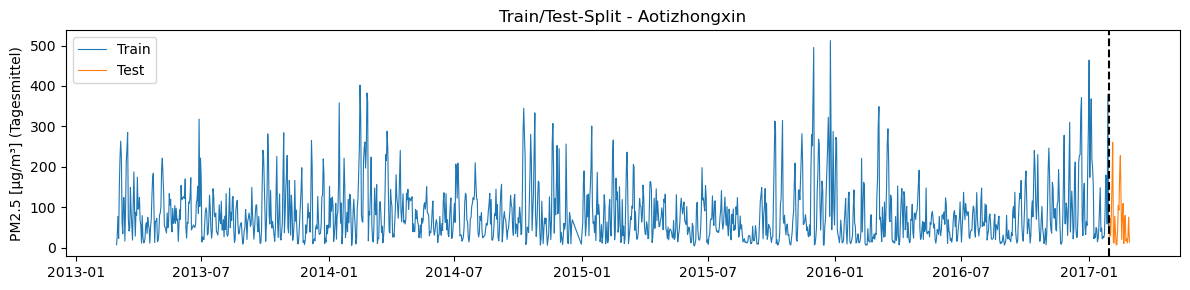

In [101]:
# Visualisierung des Splits am Beispiel einer Station
fig, ax = plt.subplots(figsize=(12, 3))
for name, part, color in [("Train", train_df, "tab:blue"), ("Test", test_df, "tab:orange")]:
    s = part.loc[part["station"] == example_station].set_index("timestamp")[TARGET_COL].resample("1D").mean()
    ax.plot(s.index, s.values, color=color, label=name, linewidth=0.8)
ax.axvline(TRAIN_END, color="black", linestyle="--")
ax.set_title(f"Train/Test-Split - {example_station}")
ax.set_ylabel("PM2.5 [µg/m³] (Tagesmittel)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Kovariaten-Strategie fuer Chronos-2

Fuer `SO2, NO2, CO, O3` liegen **zum Prognosezeitpunkt keine Werte fuer die Zukunft vor**
(anders als z.B. eine Wettervorhersage). Wuerden wir sie wie `TEMP` oder `RAIN` als
"bekannte Zukunftskovariate" behandeln, waere das **Leakage** - das Modell saehe im
Backtest Informationen, die zum echten Prognosezeitpunkt gar nicht existieren.

Wir orientieren uns an der Einordnung der vier moeglichen Strategien:

1. *Lag-Features* - einfach, aber Chronos-2 braucht das nicht (siehe Punkt 2).
2. **Past covariates** - **gewaehlt fuer Chronos-2**: Das Modell nutzt die
   *vergangenen* Werte der Schadstoff-Serien (SO2, NO2, CO, O3) als Kontext-Signal,
   ohne dass deren Zukunft bekannt sein muss. Chronos-2 unterstuetzt das nativ
   ("Past-only (real/categorical) covariates" laut Modellkarte).
3. *Kaskade (erst NO2/SO2 prognostizieren, dann als Kovariate nutzen)* - machbar, aber
   Fehlerfortpflanzung + doppelter Aufwand; hier **nicht** umgesetzt.
4. *Alle Schadstoffe gemeinsam multivariat modellieren* - als **optionales Zusatz-Experiment**
   in Abschnitt 12 (Ablation/Bonus) enthalten, um zu pruefen, ob echte Multi-Target-Prognose
   gegenueber "PM2.5 + Kovariaten" einen Mehrwert bringt.

**Konkrete Aufteilung in diesem Notebook:**

| Rolle | Spalten | In `context_df` | In `future_df` |
|---|---|---|---|
| Zielvariable | `PM2.5` | ja (Historie) | nein (wird prognostiziert) |
| Past-only Kovariaten | `SO2, NO2, CO, O3` | ja (Historie) | **nein** |
| Known-future Kovariaten (numerisch) | `TEMP, PRES, DEWP, RAIN, WSPM, wd_sin, wd_cos, days_to_cny, hour, dow, month` | ja (Historie) | **ja** (Zukunftswerte) |
| Known-future Kovariaten (kategorial) | `wd_cat`, `is_weekend`, `cny_window`, `is_public_holiday` | ja (Historie) | **ja** (Zukunftswerte) |

Chronos-2 erkennt eine Kovariate als "past-only", wenn sie in `context_df`, aber **nicht**
in `future_df` vorkommt - genau so setzen wir `SO2/NO2/CO/O3` um.

Annahme fuer `TEMP, PRES, DEWP, RAIN, WSPM, wd`: Im Backtesting verwenden wir die
**tatsaechlich gemessenen** zukuenftigen Werte als Stellvertreter fuer eine Wettervorhersage
(uebliche Annahme in der Forecasting-Literatur, "perfect weather forecast"). In der
Praxis wuerden hier reale Wettervorhersagedaten eingesetzt.

In [102]:
PAST_ONLY_COVARIATES = POLLUTANT_COVARIATES  # ["SO2", "NO2", "CO", "O3"]

KNOWN_FUTURE_NUMERIC = WEATHER_COVARIATES #+ ["wd_sin", "wd_cos", "days_to_cny", "hour", "dow", "month"]
KNOWN_FUTURE_CATEGORICAL = ["wd_cat", "is_weekend", "cny_window", "is_public_holiday"]
KNOWN_FUTURE_COVARIATES = KNOWN_FUTURE_NUMERIC + KNOWN_FUTURE_CATEGORICAL

ALL_COVARIATES = PAST_ONLY_COVARIATES + KNOWN_FUTURE_COVARIATES
print("Past-only Kovariaten:   ", PAST_ONLY_COVARIATES)
print("Known-future Kovariaten:", KNOWN_FUTURE_COVARIATES)

Past-only Kovariaten:    ['SO2', 'NO2', 'CO', 'O3']
Known-future Kovariaten: ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_cat', 'is_weekend', 'cny_window', 'is_public_holiday']


## 8. Chronos-2 laden

`Chronos2Pipeline.from_pretrained(...)` laedt das vortrainierte Modell (120M Parameter)
von Hugging Face. `device_map` wird automatisch auf `"cuda"` gesetzt, falls eine GPU
verfuegbar ist, sonst auf `"cpu"` (funktioniert, ist aber deutlich langsamer -
fuer ein vollstaendiges Backtesting ueber 12 Stationen wird eine GPU empfohlen).

In [103]:
import torch
from chronos import Chronos2Pipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Verwende Device: {DEVICE}")

pipeline = Chronos2Pipeline.from_pretrained(CHRONOS_MODEL_ID, device_map=DEVICE)

Verwende Device: cpu


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

## 9. Long-Format-DataFrames fuer `predict_df` bauen

Chronos-2 erwartet Long-Format-DataFrames mit einer ID-Spalte (Station), einer
Zeitstempel-Spalte und der/den Zielspalte(n). Wir bauen fuer einen gegebenen
Prognoseursprung (`origin`, letzter bekannter Zeitpunkt) und Horizont zwei DataFrames:

- `context_df`: alle Zeilen bis einschliesslich `origin`, mit Zielvariable + allen
  Kovariaten (past-only und known-future).
- `future_df`: die Zeilen fuer die kommenden `horizon` Stunden, **nur** mit den
  known-future-Kovariaten (keine Zielvariable, keine past-only Kovariaten).

Um alle drei Horizonte (24h/48h/72h) effizient in einem einzigen Modellaufruf
abzudecken, prognostizieren wir immer direkt **`MAX_HORIZON` = 72 Stunden (3 Tage)**
und werten anschliessend die Prognose an den Stellen `t+24h, t+48h, t+72h` aus - das
spart 3x Rechenzeit gegenueber drei separaten Aufrufen.

**Wichtig - Zeitschritte statt Stunden:** Seit der 3h-Aggregation (Abschnitt 4.3)
entspricht ein Zeitschritt `STEP_HOURS = 3` Stunden, nicht mehr 1 Stunde. `predict_df`
erwartet `prediction_length` in **Anzahl Zeitschritten**, nicht in Stunden - bei
72h Horizont sind das `72 / 3 = 24` Schritte. Ebenso beginnt `future_df` beim naechsten
Zeitschritt `origin + STEP_HOURS`, nicht `origin + 1h`.

**Wichtig - Kontextlaenge:** Chronos-2 hat laut Modellkarte eine maximale Kontextlaenge
von **8192 Zeitpunkten**. `build_context_and_future` kuerzt den Kontext daher explizit
je Station auf `MAX_CONTEXT_POINTS` (siehe Konfigurationszelle) - bei 3h-Aufloesung
sind das ~2,8 Jahre - statt sich auf eine stille interne Kuerzung der Pipeline zu
verlassen.

In [104]:
ID_COL = "station"
TS_COL = "timestamp"


def build_context_and_future(df_hist: pd.DataFrame, origin: pd.Timestamp, horizon: int,
                              use_pollutant_covariates: bool = True,
                              max_context_points: int | None = MAX_CONTEXT_POINTS):
    '''Baut context_df (Historie bis origin) und future_df (naechste `horizon` Stunden,
    in STEP_HOURS-Schritten) im Long-Format, das `Chronos2Pipeline.predict_df` erwartet.

    use_pollutant_covariates=False -> Ablation ohne SO2/NO2/CO/O3 (past-only covariates weggelassen).
    max_context_points -> je Station auf die letzten N Zeitpunkte vor/bei origin begrenzt
    (Chronos-2 max. Kontextlaenge = 8192; ohne dieses Cap wuerde die Pipeline laengere
    Historien intern selbst -- und stillschweigend -- auf die aktuellsten 8192 Punkte kuerzen).
    '''
    cov_cols = KNOWN_FUTURE_COVARIATES + (PAST_ONLY_COVARIATES if use_pollutant_covariates else [])
    context_cols = [ID_COL, TS_COL, TARGET_COL] + cov_cols
    future_cols = [ID_COL, TS_COL] + KNOWN_FUTURE_COVARIATES

    context_df = df_hist.loc[df_hist[TS_COL] <= origin, context_cols].copy()
    if max_context_points is not None:
        context_df = (
            context_df.sort_values([ID_COL, TS_COL])
            .groupby(ID_COL, group_keys=False)
            .apply(lambda g: g.tail(max_context_points))
        )

    future_start = origin + pd.Timedelta(hours=STEP_HOURS)
    future_end = origin + pd.Timedelta(hours=horizon)
    future_df = df_hist.loc[
        (df_hist[TS_COL] >= future_start) & (df_hist[TS_COL] <= future_end), future_cols
    ].copy()

    return context_df, future_df


# Kleiner Funktionstest (nur Datenaufbereitung, kein Modellaufruf)
_test_origin = TRAIN_END
_ctx, _fut = build_context_and_future(df_clean, _test_origin, horizon=24)
print("context_df:", _ctx.shape, "future_df:", _fut.shape, "(erwartet: 24/STEP_HOURS =", 24 // STEP_HOURS, "Zeilen je Station)")
print("Kontext je Station <=", MAX_CONTEXT_POINTS, "Punkte:",
      (_ctx.groupby(ID_COL).size() <= MAX_CONTEXT_POINTS).all())
assert set(PAST_ONLY_COVARIATES).isdisjoint(_fut.columns), "Past-only Kovariaten duerfen NICHT in future_df stehen!"
print("OK: past-only Kovariaten sind nicht in future_df enthalten (kein Leakage).")

context_df: (49152, 16) future_df: (48, 11) (erwartet: 24/STEP_HOURS = 4 Zeilen je Station)
Kontext je Station <= 4096 Punkte: True
OK: past-only Kovariaten sind nicht in future_df enthalten (kein Leakage).


## 10. Prognosefunktion (mehrere Horizonte, 80%-Konfidenzintervall)

`forecast_at_origin` ruft `pipeline.predict_df` **einmal** mit
`prediction_length = MAX_HORIZON // STEP_HOURS` (Anzahl 3h-Schritte, nicht Stunden!) auf
und gibt die Quantilsprognosen (10 %/50 %/90 % -> 80 %-KI) fuer **alle** Stationen
gleichzeitig zurueck (Cross-Learning zwischen den Stationen, da Chronos-2 mehrere `id`s in
einem Aufruf gemeinsam verarbeiten kann).

In [105]:
def forecast_at_origin(df_hist: pd.DataFrame, origin: pd.Timestamp,
                        use_pollutant_covariates: bool = True,
                        target: str = TARGET_COL) -> pd.DataFrame:
    '''Erzeugt eine Prognose fuer MAX_HORIZON Stunden ab `origin`, fuer alle Stationen.

    Rueckgabe: DataFrame mit Spalten [station, timestamp, predictions, <Q_LOW>, <Q_MED>, <Q_HIGH>]
    '''
    context_df, future_df = build_context_and_future(
        df_hist, origin, horizon=MAX_HORIZON, use_pollutant_covariates=use_pollutant_covariates
    )

    pred_df = pipeline.predict_df(
        context_df,
        future_df=future_df,
        prediction_length=MAX_HORIZON // STEP_HOURS,  # Anzahl Zeitschritte, nicht Stunden
        quantile_levels=QUANTILE_LEVELS,
        id_column=ID_COL,
        timestamp_column=TS_COL,
        target=target,
    )
    return pred_df


def slice_horizon(pred_df: pd.DataFrame, origin: pd.Timestamp, horizon: int) -> pd.DataFrame:
    '''Schneidet aus der MAX_HORIZON-Prognose den Zeitpunkt origin+horizon heraus (je Station).'''
    target_ts = origin + pd.Timedelta(hours=horizon)
    return pred_df.loc[pred_df[TS_COL] == target_ts].copy()

In [106]:
# Beispielhafte Einzelprognose (ein Ursprungszeitpunkt = Ende des Trainingszeitraums)
example_pred = forecast_at_origin(df_clean, TRAIN_END)
example_pred.head()

,station,timestamp,target_name,predictions,0.09999999999999998,0.5,0.9
0,Aotizhongxin,2017-01-30 00:00:00,PM2.5,12.332504,3.295891,12.332504,28.555717
1,Aotizhongxin,2017-01-30 06:00:00,PM2.5,11.971893,3.131958,11.971893,28.458439
2,Aotizhongxin,2017-01-30 12:00:00,PM2.5,13.085121,3.919037,13.085121,29.022182
3,Aotizhongxin,2017-01-30 18:00:00,PM2.5,13.285362,4.011009,13.285362,33.775410
4,Aotizhongxin,2017-01-31 00:00:00,PM2.5,15.260490,5.851196,15.260490,50.776703


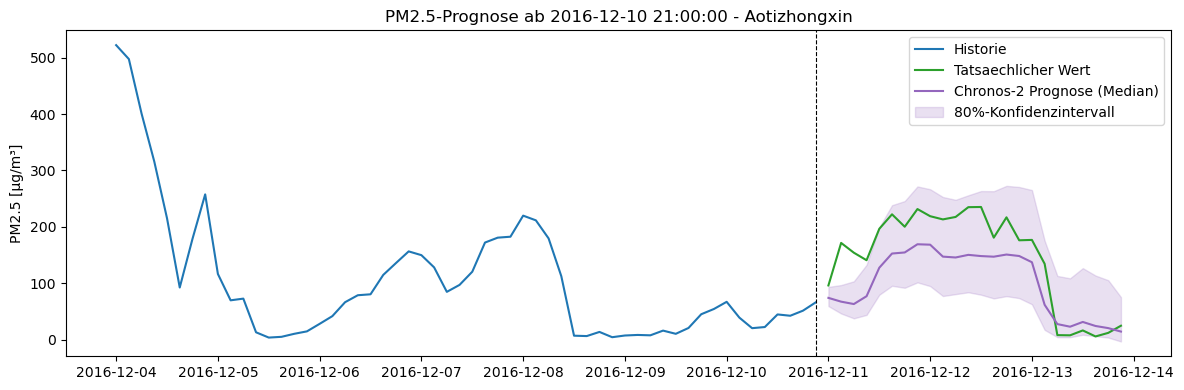

In [88]:
# Visualisierung der Beispielprognose inkl. 80%-KI fuer eine Station
def plot_forecast(df_hist, pred_df, origin, station, context_hours=7 * 24):
    ctx = df_hist.loc[
        (df_hist[ID_COL] == station) &
        (df_hist[TS_COL] > origin - pd.Timedelta(hours=context_hours)) &
        (df_hist[TS_COL] <= origin)
    ]
    truth = df_hist.loc[
        (df_hist[ID_COL] == station) &
        (df_hist[TS_COL] > origin) &
        (df_hist[TS_COL] <= origin + pd.Timedelta(hours=MAX_HORIZON))
    ]
    pred = pred_df.loc[pred_df[ID_COL] == station].sort_values(TS_COL)

    plt.figure(figsize=(12, 4))
    plt.plot(ctx[TS_COL], ctx[TARGET_COL], label="Historie", color="tab:blue")
    plt.plot(truth[TS_COL], truth[TARGET_COL], label="Tatsaechlicher Wert", color="tab:green")
    plt.plot(pred[TS_COL], pred["predictions"], label="Chronos-2 Prognose (Median)", color="tab:purple")
    plt.fill_between(pred[TS_COL], pred[Q_LOW], pred[Q_HIGH], color="tab:purple", alpha=0.2,
                      label=f"{int(CONF_LEVEL*100)}%-Konfidenzintervall")
    plt.axvline(origin, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"PM2.5-Prognose ab {origin} - {station}")
    plt.ylabel("PM2.5 [µg/m³]")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_forecast(df_clean, example_pred, TRAIN_END, example_station)

## 11. Metriken: MAPE und RMSE

`MAPE` ist bei PM2.5 kritisch, wenn die tatsaechlichen Werte nahe 0 liegen (Division durch
sehr kleine Zahlen -> extreme Ausreisser). Wir folgen dennoch der Aufgabenstellung und
berechnen den klassischen MAPE, schuetzen ihn aber mit einem kleinen Epsilon und weisen
in den Ergebnissen zusaetzlich den Anteil der Beobachtungen mit sehr niedrigem PM2.5
(< 5 µg/m³) aus, damit Ausreisser im MAPE nachvollziehbar bleiben.

In [43]:
EPS = 1e-3  # verhindert Division durch 0 im MAPE bei sehr niedrigen PM2.5-Werten


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), EPS))) * 100)


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

## 12. Sliding-Window-Backtesting

Ausgehend vom Beginn des Testzeitraums (`TRAIN_END`, `TEST_DAYS` lang) wird der
Prognoseursprung schrittweise (`BACKTEST_STEP`) durch das Testfenster geschoben. An
jedem Ursprung:

1. wird **eine** 72h-Prognose erzeugt (alle Stationen gleichzeitig),
2. werden daraus die drei Horizonte 24h/48h/72h herausgeschnitten,
3. werden MAPE und RMSE gegen die tatsaechlichen Werte berechnet.

Da der Testzeitraum jetzt nur `TEST_DAYS` Tage umfasst (statt vorher 12 Monate),
verwenden wir einen kleineren `BACKTEST_STEP` als zuvor, damit trotzdem genuegend
Ursprungszeitpunkte fuer eine aussagekraeftige Auswertung zusammenkommen.

In [44]:
BACKTEST_STEP = pd.Timedelta(days=1)  # kleinerer Schritt als vorher, da TEST_DAYS jetzt klein ist
QUICK_TEST_N_ORIGINS = 5  # fuer einen schnellen Probelauf; auf None setzen fuer volles Backtesting


def generate_backtest_origins(train_end: pd.Timestamp, data_end: pd.Timestamp,
                               max_horizon: int = MAX_HORIZON, step: pd.Timedelta = BACKTEST_STEP):
    origins = []
    o = train_end
    while o + pd.Timedelta(hours=max_horizon) <= data_end:
        origins.append(o)
        o += step
    return origins


backtest_origins = generate_backtest_origins(TRAIN_END, df_clean[TS_COL].max())
print(f"Anzahl Backtest-Ursprungszeitpunkte (voller Testzeitraum, step={BACKTEST_STEP}): {len(backtest_origins)}")

Anzahl Backtest-Ursprungszeitpunkte (voller Testzeitraum, step=1 days 00:00:00): 28


In [46]:
def run_sliding_window_backtest(df_hist: pd.DataFrame, origins: list, use_pollutant_covariates: bool = True,
                                 label: str = "mit Kovariaten") -> pd.DataFrame:
    '''Fuehrt das Sliding-Window-Backtesting durch und gibt eine lange Ergebnistabelle zurueck
    mit einer Zeile je (origin, station, horizon).'''
    records = []
    for origin in origins:
        pred_max_horizon = forecast_at_origin(df_hist, origin, use_pollutant_covariates=use_pollutant_covariates)

        for horizon_name, horizon_h in HORIZONS.items():
            pred_h = slice_horizon(pred_max_horizon, origin, horizon_h)
            target_ts = origin + pd.Timedelta(hours=horizon_h)
            truth_h = df_hist.loc[df_hist[TS_COL] == target_ts, [ID_COL, TARGET_COL]]

            merged = pred_h.merge(truth_h, on=ID_COL, suffixes=("_pred", "_true"))
            for _, row in merged.iterrows():
                records.append({
                    "origin": origin,
                    "station": row[ID_COL],
                    "horizon": horizon_name,
                    "horizon_h": horizon_h,
                    "y_true": row[TARGET_COL],
                    "y_pred": row["predictions"],
                    "q_low": row[Q_LOW],
                    "q_high": row[Q_HIGH],
                    "within_ci": (row[TARGET_COL] >= row[Q_LOW]) and (row[TARGET_COL] <= row[Q_HIGH]),
                    "variant": label,
                })
    return pd.DataFrame.from_records(records)


# --- Schneller Probelauf (wenige Ursprungszeitpunkte), zur Kontrolle vor dem vollen Backtesting ---
quick_origins = backtest_origins[:QUICK_TEST_N_ORIGINS] if QUICK_TEST_N_ORIGINS else backtest_origins
backtest_results = run_sliding_window_backtest(df_clean, quick_origins, use_pollutant_covariates=True,
                                                label="mit Kovariaten")
backtest_results.head()

KeyboardInterrupt: 

In [ ]:
# --- Volles Backtesting ueber den gesamten Testzeitraum ---
# Achtung: rechenintensiv (Anzahl Ursprungszeitpunkte x Stationen). Auf CPU ggf. BACKTEST_STEP erhoehen.
# Zum vollstaendigen Lauf QUICK_TEST_N_ORIGINS oben auf None setzen und diese Zelle ausfuehren:

# backtest_results = run_sliding_window_backtest(df_clean, backtest_origins, use_pollutant_covariates=True,
#                                                 label="mit Kovariaten")

## 13. Auswertung: MAPE & RMSE je Horizont / Station

In [47]:
def summarize_backtest(results: pd.DataFrame, groupby=("variant", "horizon")) -> pd.DataFrame:
    def _agg(g):
        return pd.Series({
            "MAPE_%": mape(g["y_true"], g["y_pred"]),
            "RMSE": rmse(g["y_true"], g["y_pred"]),
            "CI_coverage_%": g["within_ci"].mean() * 100,  # sollte nahe 80% liegen
            "n_obs": len(g),
        })

    summary = results.groupby(list(groupby)).apply(_agg).reset_index()
    # Horizonte in logischer Reihenfolge sortieren
    horizon_order = list(HORIZONS.keys())
    summary["horizon"] = pd.Categorical(summary["horizon"], categories=horizon_order, ordered=True)
    return summary.sort_values(list(groupby)).reset_index(drop=True)


summary_covariates = summarize_backtest(backtest_results)
summary_covariates

NameError: name 'backtest_results' is not defined

In [ ]:
def plot_metric_by_horizon(summary: pd.DataFrame, metric: str = "MAPE_%"):
    plt.figure(figsize=(8, 4))
    for variant, g in summary.groupby("variant"):
        g = g.sort_values("horizon")
        plt.plot(g["horizon"].astype(str), g[metric], marker="o", label=variant)
    plt.title(f"{metric} nach Prognosehorizont")
    plt.xlabel("Horizont")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_metric_by_horizon(summary_covariates, "MAPE_%")
plot_metric_by_horizon(summary_covariates, "RMSE")

In [ ]:
# Auswertung je Station (fuer den gewaehlten Backtest-Umfang)
summary_by_station = summarize_backtest(backtest_results, groupby=("station", "horizon"))
summary_by_station

## 14. Ablation: mit vs. ohne Schadstoff-Kovariaten (SO2/NO2/CO/O3)

Um den Mehrwert der zusaetzlichen Schadstoff-Zeitreihen als past-only Kovariaten zu
belegen, wiederholen wir denselben Backtest **ohne** `SO2, NO2, CO, O3`
(`use_pollutant_covariates=False`) und vergleichen die Fehlerkennzahlen.

In [48]:
backtest_results_univariate = run_sliding_window_backtest(
    df_clean, quick_origins, use_pollutant_covariates=False, label="ohne Schadstoff-Kovariaten"
)

combined_results = pd.concat([backtest_results, backtest_results_univariate], ignore_index=True)
summary_ablation = summarize_backtest(combined_results, groupby=("variant", "horizon"))
summary_ablation

KeyboardInterrupt: 

In [ ]:
plot_metric_by_horizon(summary_ablation, "MAPE_%")
plot_metric_by_horizon(summary_ablation, "RMSE")

## 15. Bonus/Experiment: echte multivariate Prognose (PM2.5 + PM10 gemeinsam)

Chronos-2 unterstuetzt neben kovariaten-informierter Prognose auch **echte multivariate
Prognose mehrerer Zielgroessen gleichzeitig** (Option 4 aus der Strategie-Uebersicht).
Als Experiment prognostizieren wir hier `PM2.5` und `PM10` gemeinsam als Zielgroessen
(`target=["PM2.5", "PM10"]`), um zu pruefen, ob die gemeinsame Modellierung gegenueber
"PM2.5 + Kovariaten" (Abschnitt 10-13) einen messbaren Unterschied macht. Dies ist ein
optionaler Test und nicht Teil des Standard-Workflows.

In [50]:
def forecast_multivariate_at_origin(df_hist: pd.DataFrame, origin: pd.Timestamp,
                                     targets=(TARGET_COL, "PM10")) -> pd.DataFrame:
    cov_cols = KNOWN_FUTURE_COVARIATES + PAST_ONLY_COVARIATES
    context_cols = [ID_COL, TS_COL] + list(targets) + cov_cols
    future_cols = [ID_COL, TS_COL] + KNOWN_FUTURE_COVARIATES

    context_df = df_hist.loc[df_hist[TS_COL] <= origin, context_cols].copy()
    context_df = (
        context_df.sort_values([ID_COL, TS_COL])
        .groupby(ID_COL, group_keys=False)
        .apply(lambda g: g.tail(MAX_CONTEXT_POINTS))
    )
    future_start = origin + pd.Timedelta(hours=STEP_HOURS)
    future_end = origin + pd.Timedelta(hours=MAX_HORIZON)
    future_df = df_hist.loc[
        (df_hist[TS_COL] >= future_start) & (df_hist[TS_COL] <= future_end), future_cols
    ].copy()

    pred_df = pipeline.predict_df(
        context_df,
        future_df=future_df,
        prediction_length=MAX_HORIZON // STEP_HOURS,  # Anzahl Zeitschritte, nicht Stunden
        quantile_levels=QUANTILE_LEVELS,
        id_column=ID_COL,
        timestamp_column=TS_COL,
        target=list(targets),
    )
    return pred_df


# Beispielaufruf (auskommentiert, da optionales Experiment):
# multivariate_pred = forecast_multivariate_at_origin(df_clean, TRAIN_END)
# multivariate_pred.head()

## 16. Zusammenfassung

- **Daten**: alle 12 Stationen werden geladen; NaNs werden **rein linear interpoliert**
  (kein Zeitlimit, ffill/bfill nur als Rand-Fallback), `wd` sowohl zyklisch (sin/cos) als
  auch kategorial kodiert.
- **Aufloesung**: Aggregation von Stunden- auf **3-Stunden-Aufloesung** (`AGG_RULE`),
  damit der Kontext trotz der Chronos-2-Grenze von `MAX_CONTEXT_POINTS = 8192` ~2,8 Jahre
  statt ~341 Tage abdeckt und volle Jahreszyklen sichtbar bleiben.
- **Horizont & Split**: maximaler Prognosehorizont **72h** (24h/48h/72h, kein 7-Tage-Horizont
  mehr); der Testzeitraum ist mit `TEST_DAYS` bewusst klein und nur so gross gewaehlt, wie
  fuer ausreichend viele Backtest-Ursprungszeitpunkte mit 72h-Vorlauf noetig - nicht mehr
  fix 12 Monate.
- **Kontextlaenge**: der Kontext wird je Station explizit auf `MAX_CONTEXT_POINTS`
  gekuerzt, statt sich auf eine stille interne Kuerzung der Pipeline zu verlassen.
- **Kovariaten-Strategie**: `SO2/NO2/CO/O3` als **past-only covariates** (kein Leakage,
  Chronos-2-native Unterstuetzung), Wetter + Kalender + Neujahrsfest als **known-future
  covariates**.
- **Chinesisches Neujahrsfest**: explizit über `days_to_cny` und `cny_window` beruecksichtigt.
- **Prognose**: Chronos-2, Horizonte 24h/48h/72h aus einem einzigen 72h-Aufruf
  (`prediction_length` in Zeitschritten, nicht Stunden!), 80 %-Konfidenzintervall ueber
  die Quantile 0.1/0.9.
- **Backtesting**: Sliding-Window ueber den (jetzt kuerzeren) Testzeitraum, Schrittweite
  `BACKTEST_STEP` (Standard: 1 Tag, anpassbar).
- **Bewertung**: MAPE, RMSE, KI-Abdeckung; Ablation mit/ohne Schadstoff-Kovariaten.

**Naechste Schritte / offene Stellschrauben:**
- `QUICK_TEST_N_ORIGINS = None` setzen fuer das vollstaendige Backtesting ueber den
  gesamten Testzeitraum (aktuell nur 5 Ursprungszeitpunkte fuer den Probelauf).
- `TEST_DAYS` / `BACKTEST_STEP` je nach gewuenschter statistischer Absicherung anpassen.
- Pruefen, ob `AGG_RULE`/`STEP_HOURS` noch feiner (z.B. 1h) oder groeber (z.B. 6h)
  sinnvoller sind - Kompromiss zwischen Detailgenauigkeit bei kurzfristigen Spitzen und
  abgedeckter Kontext-Zeitspanne.